In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut, train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, balanced_accuracy_score, matthews_corrcoef
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings("ignore")

def drop_bias(data: pd.DataFrame):
    """Removes features causing bias and unnecessary object columns."""
    bias_cols = ['merged', 'atom_site_occupancy']
    object_cols = data.select_dtypes(include=['object']).columns
    
    if len(object_cols) > 1:
        data = data.drop(columns=object_cols[-2:])
    
    return data.drop(columns=bias_cols, errors='ignore')

def balance_data(data: pd.DataFrame):
    """Balances simulated and real variants for each chromosome."""
    human_derived = data[data['driver_stat'] == 0]
    simulated_indels = data[data['driver_stat'] == 1]
    count_chrom = human_derived.groupby('chrom').size()
    sampled_simulated = []

    for chrom, count in count_chrom.items():
        sim_chrom = simulated_indels[simulated_indels['chrom'] == chrom]
        sampled_simulated.append(sim_chrom.sample(n=min(count, len(sim_chrom)), replace=False))
    
    return pd.concat([human_derived, pd.concat(sampled_simulated)], ignore_index=True)

def train_and_evaluate_model(classifier, X_train, y_train, X_test, y_test, groups):
    """Trains and evaluates the model with Leave-One-Group-Out CV and hyperparameter tuning."""
    logo = LeaveOneGroupOut()
    
    param_grid = {
        'learning_rate': [0.01, 0.1, 0.2],
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7]
    }
    
    grid_search = GridSearchCV(classifier, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
    
    best_model = None
    best_auc = -1
    
    for train_idx, val_idx in logo.split(X_train, y_train, groups):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        if len(np.unique(y_val)) < 2:
            print(f"Skipping LOGO fold with chromosome {groups[val_idx][0]} (only one class present).")
            continue  # Skip this fold
        
        sampler = RandomUnderSampler()
        X_tr_res, y_tr_res = sampler.fit_resample(X_tr, y_tr)
        
        grid_search.fit(X_tr_res, y_tr_res)
        model = grid_search.best_estimator_
        
        y_val_pred = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_val_pred)
        
        if auc > best_auc:
            best_auc = auc
            best_model = model
    
    y_test_pred = best_model.predict(X_test)
    test_results = {
        "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred),
        "recall": recall_score(y_test, y_test_pred),
        "f1": f1_score(y_test, y_test_pred),
        "roc_auc": roc_auc_score(y_test, y_test_pred),
        "mcc": matthews_corrcoef(y_test, y_test_pred)
    }
    
    return best_model, test_results

class CandrivrModel:
    def __init__(self, data_file):
        self.data = pd.read_csv(data_file, sep=',')
        self.cleaned_data = drop_bias(self.data)
        self.sampled_data = balance_data(self.cleaned_data)
        self.classifier = XGBClassifier(eval_metric='logloss')

    def prepare_data(self):
        X = self.sampled_data.drop(columns=['chrom', 'pos', 'ref_allele', 'alt_allele', 'driver_stat'])
        y = self.sampled_data['driver_stat']
        groups = self.sampled_data['chrom'].values
        unique_groups = np.unique(groups)
        np.random.shuffle(unique_groups)

        test_groups, test_size, target_size = [], 0, int(0.2 * len(y))
        for chrom in unique_groups:
            test_groups.append(chrom)
            test_size += (groups == chrom).sum()
            if test_size >= target_size:
                break
        
        test_indices = np.isin(groups, test_groups)
        X_train, X_test = X[~test_indices], X[test_indices]
        y_train, y_test = y[~test_indices], y[test_indices]
        groups_train = groups[~test_indices]
        
        return X_train, y_train, X_test, y_test, groups_train
    
    def run(self):
        X_train, y_train, X_test, y_test, groups_train = self.prepare_data()
        best_model, test_results = train_and_evaluate_model(self.classifier, X_train, y_train, X_test, y_test, groups_train)
        return best_model, test_results

# Execute
candrivr = CandrivrModel('/Users/edatkinson/Repos/Modelling/merged_and_unmerged_data.csv')
best_model, test_results = candrivr.run()
print("Final Model Performance:", test_results)





Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x13d102090>>
Traceback (most recent call last):
  File "/Users/edatkinson/anaconda3/lib/python3.12/site-packages/xgboost/core.py", line 637, in _next_wrapper
Exception ignored in: <function Booster.__del__ at 0x138c22d40>
Traceback (most recent call last):
  File "/Users/edatkinson/anaconda3/lib/python3.12/site-packages/xgboost/core.py", line 1795, in __del__
    return self._handle_exception(lambda: self.next(input_data), 0)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/edatkinson/anaconda3/lib/python3.12/site-packages/xgboost/core.py", line 550, in _handle_exception
    def __del__(self) -> None:

KeyboardInterrupt: 
    return fn()
           ^^^^
  File "/Users/edatkinson/anaconda3/lib/python3.12/site-packages/xgboost/core.py", line 637, in <lambda>
    return self._handle_exception(lambda: self.next(inp

KeyboardInterrupt: 

                                     Feature  Importance
21                             phastCons4way        97.0
1           k36.Bismap.MultiTrackMappability        40.0
14                            phastCons17way        40.0
186                    isotropic_temperature        36.0
185                             Z_coordinate        33.0
..                                       ...         ...
156                     3_Major_Groove_Width         1.0
16            k36.Umap.MultiTrackMappability         1.0
158  3_Mobility_to_bend_towards_major_groove         1.0
99                                   10_Roll         1.0
12            k50.Umap.MultiTrackMappability         1.0

[187 rows x 2 columns]


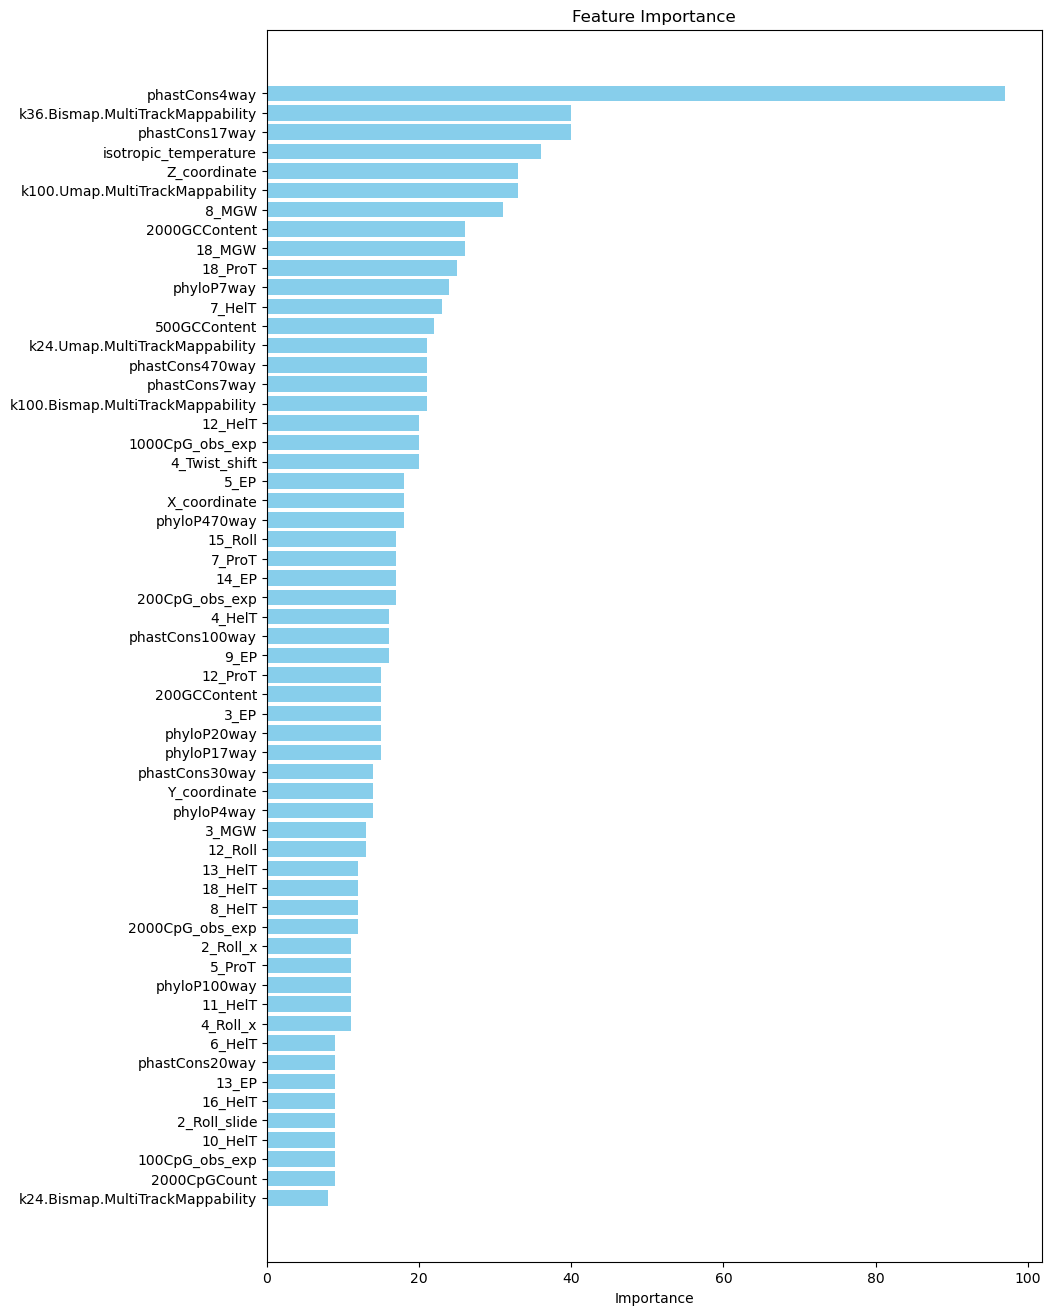

In [5]:
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance as a pandas DataFrame
importance_df = pd.DataFrame(best_model.get_booster().get_score(importance_type='weight').items(), columns=['Feature', 'Importance'])

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Print the importance
print(importance_df)

# Filter features with importance greater than 25
filtered_df = importance_df[importance_df['Importance'] > 7]

# Plotting
plt.figure(figsize=(10, 16))
plt.barh(filtered_df['Feature'], filtered_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.show()